# US Macroeconomic Data Preparation

**Imports & Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from fredapi import Fred

plt.style.use("seaborn-v0_8-darkgrid")

# ── FRED API key
# Replace with your own free key from https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "Your Key"
fred = Fred(api_key=FRED_API_KEY)

# ── Date range
START = "2007-01-01"
END   = "2023-12-31"

FRED_SERIES = {
    "CPIAUCSL" : "CPI (Inflation)",
    "UNRATE"   : "Unemployment Rate (%)",
    "FEDFUNDS" : "Fed Funds Rate (%)",
    "INDPRO"   : "Industrial Production Index",
}

print("Date range :", START, " ->  ", END)
print("Series     :", list(FRED_SERIES.keys()))

Date range : 2007-01-01  ->   2023-12-31
Series     : ['CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'INDPRO']


**Download Data from FRED API**

In [2]:
def fetch_fred(series_id, label, start, end):
    s = fred.get_series(series_id, observation_start=start, observation_end=end)
    s.index = pd.to_datetime(s.index)
    s.name  = series_id
    print(f"  [{series_id}]  {label:<35}  {len(s):>4} obs  "
          f"{s.index[0].date()} -> {s.index[-1].date()}")
    return s

print("Fetching macroeconomic data from FRED...")

cpi      = fetch_fred("CPIAUCSL", "Consumer Price Index",        START, END)
unrate   = fetch_fred("UNRATE",   "Unemployment Rate",           START, END)
fedfunds = fetch_fred("FEDFUNDS", "Fed Funds Rate",              START, END)
indpro   = fetch_fred("INDPRO",   "Industrial Production Index", START, END)

# Merge into a single monthly DataFrame
macro_raw = pd.concat([cpi, unrate, fedfunds, indpro], axis=1)
macro_raw = macro_raw.resample("MS").last()
macro_raw = macro_raw.loc[START:END]
macro_raw.index.name = "Date"

print("Combined shape :", macro_raw.shape)
print("Period         :", macro_raw.index[0].date(), " ->  ", macro_raw.index[-1].date())
macro_raw.head(8)

Fetching macroeconomic data from FRED...
  [CPIAUCSL]  Consumer Price Index                  204 obs  2007-01-01 -> 2023-12-01
  [UNRATE]  Unemployment Rate                     204 obs  2007-01-01 -> 2023-12-01
  [FEDFUNDS]  Fed Funds Rate                        204 obs  2007-01-01 -> 2023-12-01
  [INDPRO]  Industrial Production Index           204 obs  2007-01-01 -> 2023-12-01
Combined shape : (204, 4)
Period         : 2007-01-01  ->   2023-12-01


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO
Date,,,,
2007-01-01,203.437,4.6,5.25,99.8346
2007-02-01,204.226,4.5,5.26,100.7753
2007-03-01,205.288,4.4,5.26,100.9547
2007-04-01,205.904,4.5,5.25,101.6334
2007-05-01,206.755,4.4,5.25,101.7306
2007-06-01,207.234,4.6,5.25,101.7893
2007-07-01,207.603,4.7,5.26,101.6672
2007-08-01,207.667,4.6,5.02,101.8630


**Feature Engineering**

In [3]:
macro = macro_raw.copy()

# Inflation: Month-over-Month and Year-over-Year % change of CPI
macro["Inflation_MoM"] = macro["CPIAUCSL"].pct_change() * 100
macro["Inflation_YoY"] = macro["CPIAUCSL"].pct_change(12) * 100

# Industrial Production: MoM % change
macro["IP_MoM"] = macro["INDPRO"].pct_change() * 100

# UNRATE and FEDFUNDS are already in % units - no transform needed

# Drop NaN rows introduced by pct_change lags
macro = macro.dropna()

print("Engineered columns:")
for col in macro.columns:
    print("  -", col)
print("\nFinal shape:", macro.shape)
macro.describe().round(3)

Engineered columns:
  - CPIAUCSL
  - UNRATE
  - FEDFUNDS
  - INDPRO
  - Inflation_MoM
  - Inflation_YoY
  - IP_MoM

Final shape: (192, 7)


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,Inflation_MoM,Inflation_YoY,IP_MoM
count,192.000,192.000,192.000,192.000,192.000,192.000,192.000
mean,245.507,6.126,0.961,98.267,0.198,2.457,0.001
std,25.594,2.283,1.375,4.561,0.327,2.114,1.373
min,211.398,3.400,0.050,84.562,-1.771,-1.959,-13.188
25%,227.687,4.000,0.100,96.740,0.051,1.233,-0.321
50%,238.025,5.550,0.180,99.729,0.208,1.987,0.100
75%,257.070,8.025,1.550,101.256,0.335,3.163,0.469
max,308.741,14.800,5.330,104.100,1.256,8.979,6.553


**Visualisation**

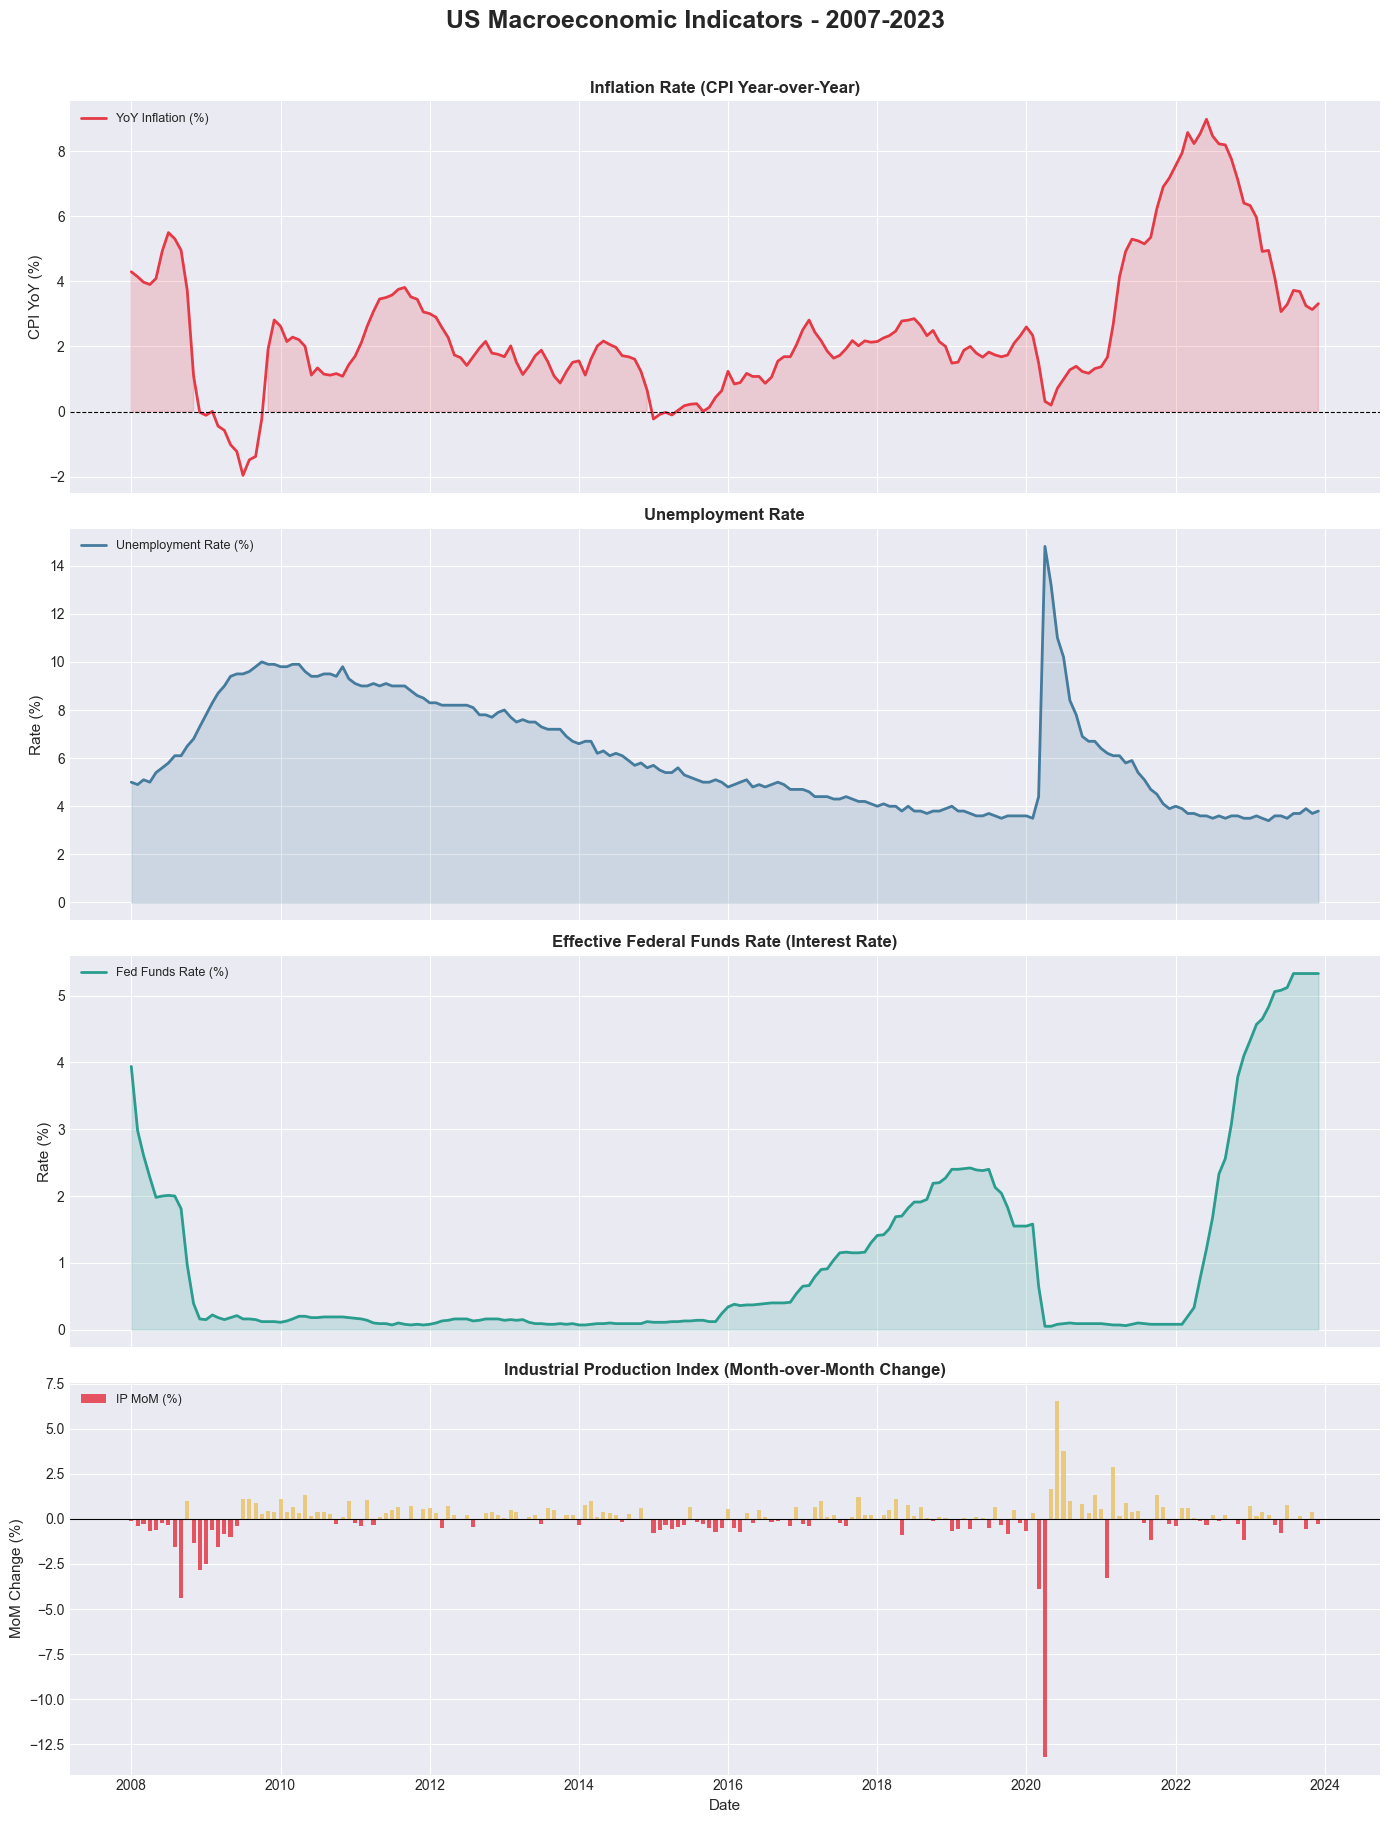

Plot saved to ../../plots/US/us_macro_indicators_2007_2023.png


In [4]:
PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"]


fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
fig.suptitle("US Macroeconomic Indicators - 2007-2023",
             fontsize=18, fontweight="bold", y=1.01)

# Panel 1: Inflation YoY
ax = axes[0]
ax.plot(macro.index, macro["Inflation_YoY"], color=PALETTE[0],
        linewidth=2, label="YoY Inflation (%)")
ax.fill_between(macro.index, macro["Inflation_YoY"], 0,
                where=(macro["Inflation_YoY"] >= 0),
                alpha=0.18, color=PALETTE[0])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("CPI YoY (%)", fontsize=11)
ax.set_title("Inflation Rate (CPI Year-over-Year)", fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 2: Unemployment Rate
ax = axes[1]
ax.plot(macro.index, macro["UNRATE"], color=PALETTE[1],
        linewidth=2, label="Unemployment Rate (%)")
ax.fill_between(macro.index, macro["UNRATE"], alpha=0.18, color=PALETTE[1])
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Unemployment Rate", fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 3: Federal Funds Rate
ax = axes[2]
ax.plot(macro.index, macro["FEDFUNDS"], color=PALETTE[2],
        linewidth=2, label="Fed Funds Rate (%)")
ax.fill_between(macro.index, macro["FEDFUNDS"], alpha=0.18, color=PALETTE[2])
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Effective Federal Funds Rate (Interest Rate)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 4: Industrial Production MoM %
ax = axes[3]
bar_colors = [PALETTE[3] if v >= 0 else PALETTE[0] for v in macro["IP_MoM"]]
ax.bar(macro.index, macro["IP_MoM"], width=20,
       color=bar_colors, alpha=0.85, label="IP MoM (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("MoM Change (%)", fontsize=11)
ax.set_title("Industrial Production Index (Month-over-Month Change)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Shared x-axis
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date", fontsize=11)
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

import os
os.makedirs("../../plots/US", exist_ok=True)
plt.savefig("../../plots/US/us_macro_indicators_2007_2023.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to ../../plots/US/us_macro_indicators_2007_2023.png")

# FinBERT Sentiment Scoring

**Config & Load Raw News**

In [5]:
import os, re
import pandas as pd

NEWS_PATH       = "../../data/raw/US/FinSen_US_Categorized_Timestamp.csv"
CHECKPOINT_DIR  = "../../data/processed/US/finbert_checkpoints"   
FINAL_CACHE     = "../../data/processed/US/finbert_article_scores.csv"
BATCH_SIZE      = 128    
MAX_CHARS       = 512  

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("../../data/processed/US", exist_ok=True)

def clean(text, max_chars=MAX_CHARS):
    text = str(text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text[:max_chars]


news_raw = pd.read_csv(NEWS_PATH)
news_raw = news_raw[["Title", "Content", "Time"]].copy()
news_raw.rename(columns={"Time": "Date"}, inplace=True)
news_raw["Date"] = pd.to_datetime(news_raw["Date"], dayfirst=True)
news_raw = news_raw.dropna(subset=["Title", "Content", "Date"]).reset_index(drop=True)
news_raw["text"] = (
    news_raw["Title"].apply(clean) + ". " + news_raw["Content"].apply(clean)
).str[:MAX_CHARS]

print(f"Articles loaded : {len(news_raw)}")
print(f"Date range      : {news_raw['Date'].min().date()} to {news_raw['Date'].max().date()}")
news_raw.head(3)


Articles loaded : 15534
Date range      : 2007-06-04 to 2023-07-16


,Title,Content,Date,text
0,"TSX Slightly Down, Books Weekly Gains","TSX Slightly Down, Books Weekly GainsUnited St...",2023-07-16,"TSX Slightly Down, Books Weekly Gains. TSX Sli..."
1,UnitedHealth Hits 4-week High,UnitedHealth Hits 4-week HighUnited States sto...,2023-07-15,UnitedHealth Hits 4-week High. UnitedHealth Hi...
2,Cisco Systems Hits 4-week Low,Cisco Systems Hits 4-week LowUnited States sto...,2023-07-15,Cisco Systems Hits 4-week Low. Cisco Systems H...


**Load FinBERT Pipeline**

In [6]:
import torch
import transformers
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

device       = 0 if torch.cuda.is_available() else -1
device_label = "GPU" if device == 0 else "CPU"
print(f"transformers : {transformers.__version__}")
print(f"torch        : {torch.__version__}")
print(f"Device       : {device_label}")

# Load model & tokenizer explicitly 
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model     = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")

finbert = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    device=device,
    truncation=True,
    max_length=512,
)
print("FinBERT ready.")


transformers : 4.24.0
torch        : 1.7.1+cu101
Device       : GPU
FinBERT ready.


**Batch Inference with Per-Batch Checkpointing**

In [7]:
# Safe to re-run after a crash: already-scored batches are automatically skipped.
from tqdm.auto import tqdm
import os

def net_score(preds):
    """P(positive) - P(negative) net sentiment."""
    prob = {p["label"]: p["score"] for p in preds}
    return prob.get("positive", 0.0) - prob.get("negative", 0.0)

texts     = news_raw["text"].tolist()
n_batches = (len(texts) + BATCH_SIZE - 1) // BATCH_SIZE

# ── Detect already-completed batches
existing = {
    int(f.split("_")[1].split(".")[0])
    for f in os.listdir(CHECKPOINT_DIR)
    if f.startswith("batch_") and f.endswith(".csv")
}
pending = [i for i in range(n_batches) if i not in existing]

print(f"Total batches : {n_batches}")
print(f"Already done  : {len(existing)}")
print(f"Remaining     : {len(pending)}")

for batch_idx in tqdm(pending, desc="FinBERT batches"):
    start = batch_idx * BATCH_SIZE
    end   = min(start + BATCH_SIZE, len(texts))
    batch_texts = texts[start:end]

    try:
        out = finbert(batch_texts)
    except Exception as exc:
        print(f"  [!] Batch {batch_idx} failed: {exc}  – skipping")
        continue

    batch_df = news_raw.iloc[start:end][["Date", "Title"]].copy().reset_index(drop=True)
    batch_df["Sentiment_Score"] = [net_score(r) for r in out]
    batch_df["Label"]           = [max(r, key=lambda x: x["score"])["label"] for r in out]

    ckpt_path = os.path.join(CHECKPOINT_DIR, f"batch_{batch_idx:05d}.csv")
    batch_df.to_csv(ckpt_path, index=False)

print(f"\nInference complete (or resumed). Checkpoint files in {CHECKPOINT_DIR}:",
      len(os.listdir(CHECKPOINT_DIR)))


Total batches : 122
Already done  : 80
Remaining     : 42


FinBERT batches: 100%|██████████| 42/42 [04:30<00:00,  6.44s/it]


Inference complete (or resumed). Checkpoint files in ../../data/processed/US/finbert_checkpoints: 122


**Assemble scores_df from Checkpoints & Save Final Cache**

In [8]:
import glob
import pandas as pd
import os

ckpt_files = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "batch_*.csv")))
if not ckpt_files:
    raise RuntimeError("No checkpoint files found – run Cell 10c first.")

scores_df = pd.concat(
    [pd.read_csv(f, parse_dates=["Date"]) for f in ckpt_files],
    ignore_index=True
).sort_values("Date").reset_index(drop=True)

scores_df.to_csv(FINAL_CACHE, index=False)
print(f"Final cache saved  : {FINAL_CACHE}")
print(f"Total articles     : {len(scores_df)}")
print(f"Date range         : {scores_df['Date'].min().date()} to {scores_df['Date'].max().date()}")
scores_df.head()


Final cache saved  : ../../data/processed/US/finbert_article_scores.csv
Total articles     : 15534
Date range         : 2007-06-04 to 2023-07-16


,Date,Title,Sentiment_Score,Label
0,2007-06-04,Blackstone boosts IPO after Beijing takes $3bn...,0.896313,positive
1,2007-06-04,Trade Deficit Increases in March 2007,0.423149,positive
2,2007-06-06,Consumer Price Index 2.6 percent higher than i...,0.866791,positive
3,2007-06-06,"Nonfarm payroll employment increased by 157,00...",0.705184,positive
4,2007-06-06,U.S. Federal Reserve Kept Rates Unchanged at 5...,-0.149566,neutral


**Monthly Aggregation & Sentiment Plot**

Monthly sentiment computed for 194 months
Period: 2007-06-01 to 2023-07-01


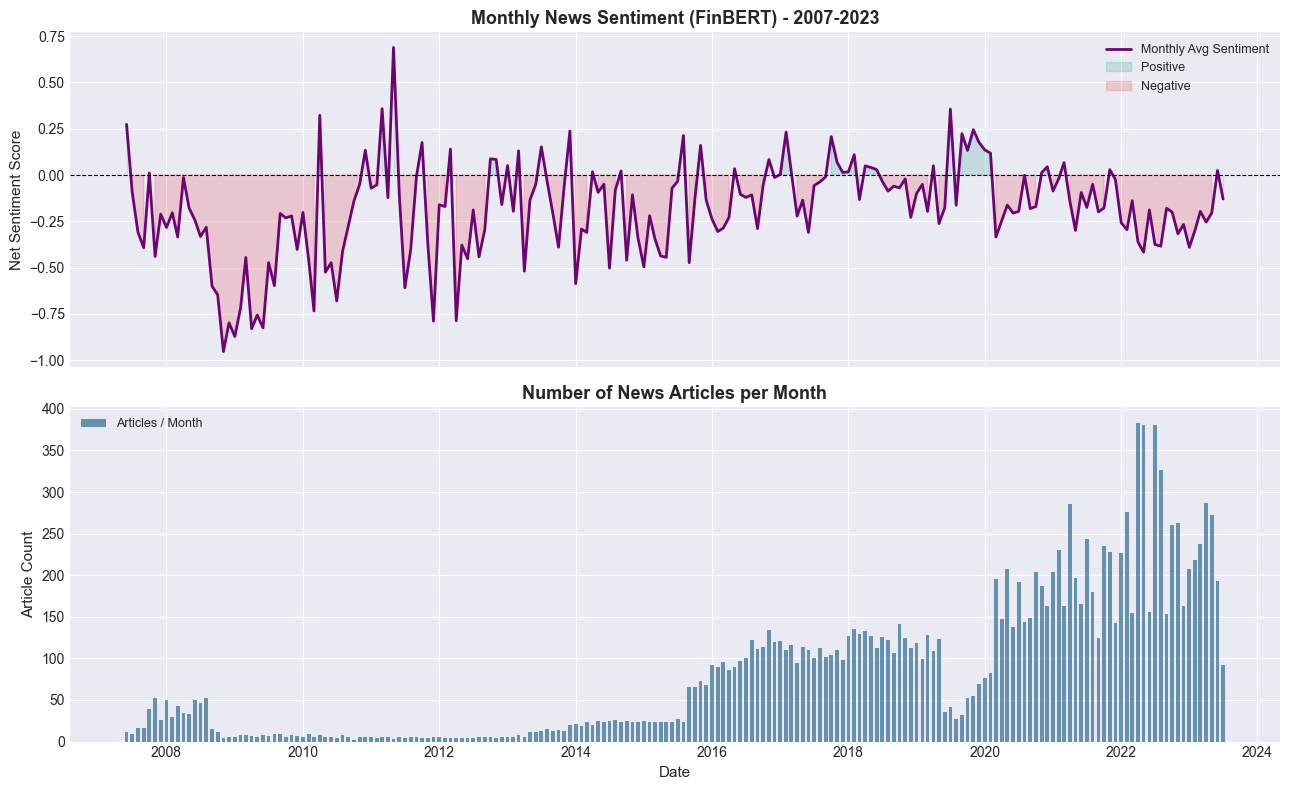

Sentiment plot saved to ../../plots/US/us_news_sentiment_2007_2023.png


In [11]:
# Monthly mean sentiment score and article count
scores_df["Date"]  = pd.to_datetime(scores_df["Date"])
scores_df["Month"] = scores_df["Date"].dt.to_period("M").dt.to_timestamp()

monthly_sent = (
    scores_df
    .groupby("Month")
    .agg(
        News_Sentiment=("Sentiment_Score", "mean"),
        Article_Count=("Sentiment_Score", "count"),
    )
    .rename_axis("Date")
)

print("Monthly sentiment computed for", len(monthly_sent), "months")
print("Period:", monthly_sent.index[0].date(), "to", monthly_sent.index[-1].date())

# ── Plot: sentiment over time
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(monthly_sent.index, monthly_sent["News_Sentiment"],
        color="#6A0572", linewidth=2, label="Monthly Avg Sentiment")
ax.fill_between(monthly_sent.index, monthly_sent["News_Sentiment"], 0,
                where=(monthly_sent["News_Sentiment"] >= 0),
                alpha=0.2, color="#2A9D8F", label="Positive")
ax.fill_between(monthly_sent.index, monthly_sent["News_Sentiment"], 0,
                where=(monthly_sent["News_Sentiment"] < 0),
                alpha=0.2, color="#E63946", label="Negative")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Net Sentiment Score", fontsize=11)
ax.set_title("Monthly News Sentiment (FinBERT) - 2007-2023",
             fontsize=13, fontweight="semibold")
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(monthly_sent.index, monthly_sent["Article_Count"],
       width=20, color="#457B9D", alpha=0.8, label="Articles / Month")
ax.set_ylabel("Article Count", fontsize=11)
ax.set_title("Number of News Articles per Month", fontsize=13, fontweight="semibold")
ax.legend(fontsize=9)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date", fontsize=11)
plt.tight_layout()
plt.savefig("../../plots/US/us_news_sentiment_2007_2023.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sentiment plot saved to ../../plots/US/us_news_sentiment_2007_2023.png")

**Merge with Macro Data & Save Final Dataset**

In [13]:
import os

# Align monthly sentiment index with macro DataFrame index
monthly_sent.index = pd.to_datetime(monthly_sent.index)
macro.index        = pd.to_datetime(macro.index)

# Left-join so all macro months are kept; sentiment is NaN where no articles exist
df_final = macro.join(monthly_sent[["News_Sentiment", "Article_Count"]], how="left")
df_final = df_final[df_final.index <= "2023-07-01"]

print("Merge summary:")
print("  Macro rows            :", len(macro))
print("  Months with sentiment :", df_final["News_Sentiment"].notna().sum())
print("  Months without        :", df_final["News_Sentiment"].isna().sum())

# Save final processed dataset
os.makedirs("../data/processed/US", exist_ok=True)
out_path = "../data/processed/US/us_macro_2007_2023.csv"
df_final.to_csv(out_path)

print("\nProcessed dataset saved to", out_path)
print("  Shape   :", df_final.shape)
print("  Columns :", list(df_final.columns))
print("  Period  :", df_final.index[0].date(), "to", df_final.index[-1].date())
df_final.tail()

Merge summary:
  Macro rows            : 192
  Months with sentiment : 187
  Months without        : 0

Processed dataset saved to ../data/processed/US/us_macro_2007_2023.csv
  Shape   : (187, 9)
  Columns : ['CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'INDPRO', 'Inflation_MoM', 'Inflation_YoY', 'IP_MoM', 'News_Sentiment', 'Article_Count']
  Period  : 2008-01-01 to 2023-07-01


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,Inflation_MoM,Inflation_YoY,IP_MoM,News_Sentiment,Article_Count
Date,,,,,,,,,
2023-03-01,301.821,3.5,4.65,101.0205,0.123072,4.917719,0.376484,-0.196047,238.0
2023-04-01,302.845,3.4,4.83,101.2530,0.339274,4.950080,0.230151,-0.253936,287.0
2023-05-01,303.334,3.6,5.06,100.9286,0.161469,4.131851,-0.320386,-0.205240,272.0
2023-06-01,304.014,3.6,5.08,100.1196,0.224175,3.070617,-0.801557,0.024506,193.0
2023-07-01,304.609,3.5,5.12,100.9067,0.195715,3.287749,0.786160,-0.129719,92.0
